# Full Monte Carlo uncertainty budget

## What this notebook does

We run a large Monte Carlo (N_MC samples) at the Planck baryon density, drawing
**three independent sources of uncertainty** simultaneously:

1. **Nuclear rates** — each of the 12 key reaction rates is multiplied by
   $\exp(p_i \sigma_i)$ where $p_i \sim \mathcal{N}(0,1)$ and $\sigma_i$ is the
   tabulated 1σ rate uncertainty.

2. **Neutron lifetime** $\tau_n$ — drawn from
   $\mathcal{N}(878.4,\, 0.5)$ s (PDG 2022 average).
   The neutron lifetime sets the overall normalisation of the n↔p weak rates
   and is the dominant single-parameter uncertainty on $Y_P$.

3. **Baryon density** $\Omega_b h^2$ — drawn from the Planck 2018 posterior
   $\mathcal{N}(0.02237,\, 0.00015)$.

The result is a joint sample of $(Y_P,\, {\rm D/H},\, {}^3{\rm He/H},\, {}^7{\rm Li/H})$
that captures the full theoretical uncertainty budget.
We then plot histograms of each observable and a corner plot showing pairwise correlations.

**Note:** for a quick test use N_MC = 50; for publication quality use N_MC ≥ 500.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

import numpy as np
import matplotlib.pyplot as plt
import multiprocessing
from joblib import Parallel, delayed

from primat.config import DEFAULT_PARAMS
from primat.backend import run_bbn
from primat.config import PRIMATConfig

**Why not `run_mc` here?** This notebook's Monte Carlo jointly varies **three** independent sources of uncertainty per sample: the 12 nuclear rate offsets, $\tau_n$, *and* $\Omega_b h^2$. `primat.backend.run_mc` only randomises nuclear rates/$\tau_n$ around a *fixed* set of base `params` -- it has no mechanism to draw $\Omega_b h^2$ (or any other cosmological/physical parameter) per sample. `run_mc` is the right tool whenever a scan only needs rate/$\tau_n$ uncertainty at fixed cosmological parameters, e.g.:
```python
from primat.backend import run_mc
mc = run_mc(50, ['YPBBN', 'DoH'], params={'network': 'small', 'Omegabh2': 0.02285})
```
Here we instead keep the explicit per-sample loop below, calling `primat.backend.run_bbn(params)` directly for each draw -- same backend-dispatch story as `run_bbn`/`run_mc` elsewhere (C extension when available, else pure Python), just driven by our own sampler since the 3-way joint draw is broader than what `run_mc` natively expresses.


## Parallelization: Python backend (joblib) vs C backend (pthread)

This notebook uses **joblib.Parallel** to parallelize the Monte Carlo samples across worker processes (one BBN solve per worker). By default, `N_JOBS = multiprocessing.cpu_count()` so the job runs on all available cores.

**Note on backends:**
- **Python backend** (default if C extension unavailable): each `run_bbn` call dispatches to the pure-Python solver; joblib orchestrates the parallelization.
- **C backend** (default if available, see `primat.backend.run_bbn()`): `run_bbn` internally uses the fast compiled C extension. When called from joblib workers, each worker still runs the C code, so you get both C's speed advantage *and* joblib's parallelization.

Both backends produce **statistically equivalent** results (mean, std, correlations agree to numerical precision ~1e-7–1e-8), but individual samples are not bit-for-bit identical due to different RNG implementations:
- Python: NumPy's `default_rng` per worker
- C: xoshiro256** PRNG per thread

For comparison, you can force the Python backend in cell-3 by adding `os.environ['PRIMAT_BACKEND_LOG'] = '1'` and checking the output logs, or by passing `force_backend='python'` to `run_bbn`.

In [2]:
# ---------------------------------------------------------------------------
# Parameters
# ---------------------------------------------------------------------------

N_MC    = 100 #100       # number of MC samples (use ≥500 for publication quality)
N_JOBS  = multiprocessing.cpu_count()
MC_SEED = 0        # fixed seed for reproducibility

# Planck 2018 baryon density prior (TT+TE+EE+lowE+lensing)
OMEGA_B_H2_MEAN = 0.02285
OMEGA_B_H2_STD  = 0.00016

# Neutron lifetime prior (PDG 2022 average)
TAU_N_MEAN = 878.4   # s
TAU_N_STD  =   0.5   # s (1σ)

# The 12 key nuclear rate keys in DEFAULT_PARAMS
RATE_KEYS = list(PRIMATConfig().p_rxn.keys())[:12]

print(f"N_MC = {N_MC}, running on {N_JOBS} CPUs")
print(f"Nuclear rate keys: {RATE_KEYS}")


N_MC = 100, running on 8 CPUs
Nuclear rate keys: ['n_p__d_g', 'd_p__He3_g', 't_d__a_n', 't_a__Li7_g', 'He3_d__a_p', 'He3_n__t_p', 'Li7_p__a_a', 'd_d__He3_n', 'Be7_n__Li7_p', 'd_d__t_p', 't_p__a_g', 'He3_a__Be7_g']


In [3]:
# ---------------------------------------------------------------------------
# Worker function (module-level so joblib can pickle it)
# ---------------------------------------------------------------------------
# Each call:
#   1. Draws Ω_b h² from the Planck prior
#   2. Draws τ_n from its measurement uncertainty
#   3. Draws all 12 nuclear rate offsets p_i ~ N(0,1)
#   4. Runs a full run_bbn and returns the four key observables

def _run_one_full_mc(seed):
    import sys, os
    sys.path.insert(0, os.path.abspath('..'))
    import numpy as np
    from primat.config import DEFAULT_PARAMS
    from primat.backend import run_bbn

    rate_keys = [k for k in DEFAULT_PARAMS if k.startswith('p_')][:12]
    rng = np.random.default_rng(seed)

    ob2   = rng.normal(OMEGA_B_H2_MEAN, OMEGA_B_H2_STD)          # Ω_b h²
    tau_n = rng.normal(TAU_N_MEAN, TAU_N_STD)                 # τ_n [s]
    p_vec = rng.standard_normal(len(rate_keys))    # nuclear rate offsets

    params = {
        'Omegabh2':          ob2,
        'tau_n':             tau_n,
        'network': 'small',
        'verbose':      False,
        'debug':        False,
        **{k: float(v) for k, v in zip(rate_keys, p_vec)},
    }
    r = run_bbn(params)
    return (
        ob2, tau_n,
        r['YPBBN'],
        r['DoH'],
        r['He3oH'],
        r['Li7oH'],
    )

print("Worker function defined.")


Worker function defined.


In [4]:
# ---------------------------------------------------------------------------
# Run the Monte Carlo
# ---------------------------------------------------------------------------
print(f"Running {N_MC} full MC samples ...")

raw = Parallel(n_jobs=N_JOBS)(
    delayed(_run_one_full_mc)(MC_SEED + i) for i in range(N_MC)
)

raw = np.array(raw)   # shape (N_MC, 6)
ob2_s, taun_s, YP_s, DoH_s, He3oH_s, Li7oH_s = raw.T

print(f"Done. Shapes: {YP_s.shape}")
print(f"  YP    : {YP_s.mean():.6f} ± {YP_s.std():.6f}")
print(f"  D/H   : {DoH_s.mean():.4e} ± {DoH_s.std():.4e}")
print(f"  He3/H : {He3oH_s.mean():.4e} ± {He3oH_s.std():.4e}")
print(f"  Li7/H : {Li7oH_s.mean():.4e} ± {Li7oH_s.std():.4e}")

Running 100 full MC samples ...


Done. Shapes: (100,)
  YP    : 0.247173 ± 0.000126
  D/H   : 2.3639e-05 ± 2.6078e-07
  He3/H : 1.0291e-05 ± 3.9549e-08
  Li7/H : 5.7721e-10 ± 7.9937e-12


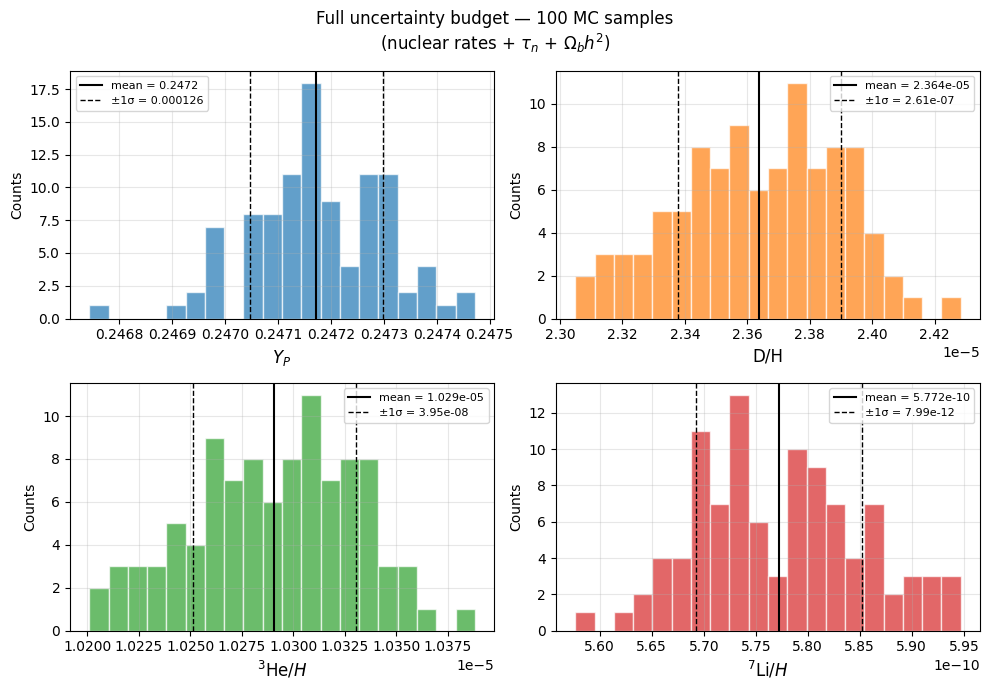

In [5]:
# ---------------------------------------------------------------------------
# Histograms of each observable
# ---------------------------------------------------------------------------
# Each histogram shows the full theoretical uncertainty from nuclear rates,
# τ_n, and Ω_b h² combined.  The dashed vertical lines mark the ±1σ range.

obs_info = [
    (YP_s,    r'$Y_P$',             'tab:blue'),
    (DoH_s,   r'D/H',               'tab:orange'),
    (He3oH_s, r'$^3{\rm He}/H$',    'tab:green'),
    (Li7oH_s, r'$^7{\rm Li}/H$',    'tab:red'),
]

fig, axs = plt.subplots(2, 2, figsize=(10, 7))
axs = axs.flatten()

for ax, (samples, label, color) in zip(axs, obs_info):
    mu, sig = samples.mean(), samples.std()
    ax.hist(samples, bins=20, color=color, alpha=0.7, edgecolor='white')
    ax.axvline(mu,        color='black', lw=1.5, ls='-',  label=f'mean = {mu:.4g}')
    ax.axvline(mu - sig,  color='black', lw=1,   ls='--', label=f'±1σ = {sig:.3g}')
    ax.axvline(mu + sig,  color='black', lw=1,   ls='--')
    ax.set_xlabel(label, fontsize=12)
    ax.set_ylabel('Counts', fontsize=10)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

fig.suptitle(f'Full uncertainty budget — {N_MC} MC samples\n'
             r'(nuclear rates + $\tau_n$ + $\Omega_b h^2$)', fontsize=12)
plt.tight_layout()
plt.savefig('plots/mc_rates_histograms.pdf', bbox_inches='tight')
plt.show()

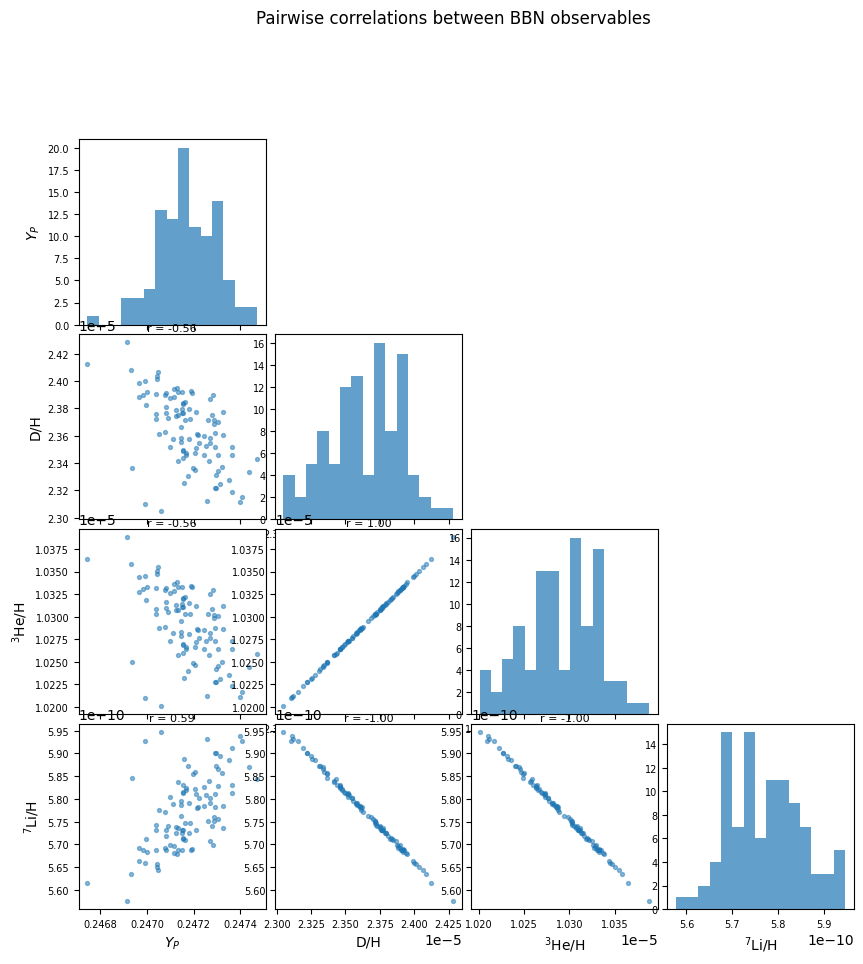

In [6]:
# ---------------------------------------------------------------------------
# Corner plot — pairwise correlations between observables
# ---------------------------------------------------------------------------
# Strong correlations reveal which observables share common rate dependencies.
# For example, YP and D/H are anti-correlated through the p+n→d+γ rate:
# a faster reaction depletes free neutrons faster, lowering YP and increasing D.

labels = [r'$Y_P$', r'D/H', r'$^3$He/H', r'$^7$Li/H']
samples_all = np.column_stack([YP_s, DoH_s, He3oH_s, Li7oH_s])
n = len(labels)

fig, axs = plt.subplots(n, n, figsize=(10, 10))
fig.subplots_adjust(hspace=0.05, wspace=0.05)

for i in range(n):
    for j in range(n):
        ax = axs[i, j]
        if i == j:
            # Diagonal: histogram
            ax.hist(samples_all[:, i], bins=15, color='tab:blue', alpha=0.7)
        elif i > j:
            # Lower triangle: scatter plot
            ax.scatter(samples_all[:, j], samples_all[:, i],
                       s=8, alpha=0.5, color='tab:blue')
            # Pearson correlation coefficient
            rho = np.corrcoef(samples_all[:, j], samples_all[:, i])[0, 1]
            ax.set_title(f'r = {rho:.2f}', fontsize=8, pad=2)
        else:
            ax.set_visible(False)

        # Labels only on edges
        if j == 0:
            ax.set_ylabel(labels[i], fontsize=10)
        if i == n - 1:
            ax.set_xlabel(labels[j], fontsize=10)
        ax.tick_params(labelsize=7)

fig.suptitle('Pairwise correlations between BBN observables', fontsize=12, y=1.01)
plt.savefig('plots/mc_rates_corner.pdf', bbox_inches='tight')
plt.show()

In [7]:
# ---------------------------------------------------------------------------
# Summary table
# ---------------------------------------------------------------------------
print(f"{'Observable':<15}  {'Mean':>14}  {'1σ':>12}  {'1σ/mean':>10}")
print('-' * 58)
for samples, label in [(YP_s, 'YP'), (DoH_s, 'D/H'),
                        (He3oH_s, 'He3/H'), (Li7oH_s, 'Li7/H')]:
    mu, sig = samples.mean(), samples.std()
    print(f"{label:<15}  {mu:>14.6e}  {sig:>12.4e}  {sig/mu*100:>9.3f}%")

Observable                 Mean            1σ     1σ/mean
----------------------------------------------------------
YP                 2.471728e-01    1.2610e-04      0.051%
D/H                2.363869e-05    2.6078e-07      1.103%
He3/H              1.029068e-05    3.9549e-08      0.384%
Li7/H              5.772098e-10    7.9937e-12      1.385%
